# Conditional GAN para generar escenarios BTC–ETH

Este notebook implementa el **tercer modelo generativo neuronal** del proyecto: una GAN condicional (`cGAN`) aplicada al mismo problema BTC–ETH que el CVAE y el Normalizing Flow.

El recorrido es:

1. cargar el mismo split temporal y la misma normalización del proyecto;
2. comparar varias configuraciones usando **solo validación**;
3. entrenar una GAN condicional con generador y discriminador adversariales;
4. seleccionar el checkpoint por calidad sintética en validación, no por test;
5. generar múltiples trayectorias BTC–ETH para una misma condición;
6. evaluar el modelo con el `TrajectoryEvaluator` común;
7. medir el impacto de la augmentación `0 / +25 / +50 / +100 %` sobre el mismo modelo downstream usado por el Flow;
8. guardar resultados y checkpoints de forma reproducible.

El objetivo sigue siendo aprender la **distribución condicional de trayectorias futuras** de BTC y ETH durante 30 días, dado el estado de mercado observado en los 60 días anteriores.

## Relación con los otros modelos y decisiones metodológicas

Para que la comparación sea coherente mantenemos las decisiones comunes del repositorio:

- trayectorias conjuntas de 120 velas de seis horas, con BTC y ETH generados conjuntamente;
- condición de 14 variables construida por el pipeline común;
- entrenamiento restringido a `train`, selección con `validation` y evaluación final en `test`;
- retornos logarítmicos desnormalizados antes de calcular métricas financieras;
- las mismas familias del `TrajectoryEvaluator` común;
- control adicional con objetivos no solapados;
- en downstream, exactamente la misma MLP, escalado, semillas y bloques reales de validación/test que en el Normalizing Flow.

La GAN añade una tercera familia generativa distinta: **entrenamiento adversarial**. El generador intenta producir trayectorias que el discriminador no pueda distinguir de las reales para la misma condición de mercado.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass, replace
from pathlib import Path
import copy
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from crypto_generative.evaluation import (
    CrossAssetDependenceConfig,
    DiversityMemorizationConfig,
    RiskMetricsConfig,
    TemporalDependenceConfig,
    TrajectoryEvaluator,
    TrajectoryMetricsConfig,
)

DATASET_PATH = ROOT / "data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz"
SPLIT_PATH = ROOT / "data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz"
OUTPUT_DIR = ROOT / "outputs/conditional_gan_best"

SEED = 42
SCENARIOS_PER_CONDITION = 20
DEVICE = torch.device("cpu")  # reproducibilidad y compatibilidad con el resto del proyecto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
print("Raíz del proyecto detectada:", ROOT.name)

PyTorch: 2.13.0
Dispositivo: cpu
Raíz del proyecto detectada: Taller_Generativos


## 1. Dataset y split temporal

Cada muestra contiene:

- `condition_features`: 14 variables normalizadas que resumen los 60 días anteriores;
- `target_returns`: una matriz `(120, 2)` con los retornos de seis horas de BTC y ETH durante los siguientes 30 días.

Usamos exactamente los artefactos congelados del proyecto. La normalización fue ajustada únicamente con train y los bloques temporales están separados mediante purga.

In [2]:
with np.load(DATASET_PATH, allow_pickle=False) as data:
    conditions = data["condition_features"].astype(np.float32)
    targets = data["target_returns"].astype(np.float32)
    feature_names = data["feature_names"].copy()
    assets = data["assets"].copy()
    return_mean = data["return_mean"].astype(np.float32)
    return_scale = data["return_scale"].astype(np.float32)

with np.load(SPLIT_PATH, allow_pickle=False) as split:
    train_ids = split["train_sample_ids"].copy()
    validation_ids = split["validation_sample_ids"].copy()
    test_ids = split["test_sample_ids"].copy()

x_train, c_train = targets[train_ids], conditions[train_ids]
x_validation, c_validation = targets[validation_ids], conditions[validation_ids]
x_test, c_test = targets[test_ids], conditions[test_ids]

dataset_summary = pd.DataFrame({
    "bloque": ["train", "validación", "test"],
    "muestras": [len(x_train), len(x_validation), len(x_test)],
    "objetivo": [str(x_train.shape[1:]), str(x_validation.shape[1:]), str(x_test.shape[1:])],
    "condición": [str(c_train.shape[1:]), str(c_validation.shape[1:]), str(c_test.shape[1:])],
})
display(dataset_summary)
print("Activos:", assets.tolist())
print("Variables de condición:", len(feature_names))

,bloque,muestras,objetivo,condición
0,train,4710,"(120, 2)","(14,)"
1,validación,1832,"(120, 2)","(14,)"
2,test,1826,"(120, 2)","(14,)"


Activos: ['BTC', 'ETH']
Variables de condición: 14


Las ventanas se desplazan una vela cada vez y se solapan mucho. Son útiles para entrenar, pero no equivalen al mismo número de historias económicas independientes. Al final repetiremos parte de la evaluación con anclas separadas por 120 velas.

## 2. Configuración y búsqueda

Una GAN no dispone de likelihood exacta como el Flow. Además, sus pérdidas adversariales no son por sí solas una medida fiable de calidad sintética. Por eso la selección se hace con **métricas financieras sobre validación**.

Probamos tres configuraciones compactas de una `cGAN` MLP. Cada candidata se entrena durante un número reducido de épocas y se evalúa periódicamente sobre un subconjunto fijo de validación. El score de selección combina:

- Wasserstein-1 marginal normalizada de BTC y ETH;
- error absoluto de correlación contemporánea BTC–ETH;
- Wasserstein-1 normalizada del retorno log acumulado a 30 días.

Cuanto menor sea el score, mejor. **Test no participa en ninguna decisión.**

In [3]:
@dataclass(frozen=True)
class GANConfig:
    trajectory_length: int = 120
    n_assets: int = 2
    condition_dim: int = 14
    latent_dim: int = 64
    generator_hidden_dim: int = 256
    discriminator_hidden_dim: int = 256
    generator_lr: float = 2e-4
    discriminator_lr: float = 1e-4
    batch_size: int = 128
    epochs: int = 80
    eval_every: int = 5
    real_label_smoothing: float = 0.90
    discriminator_dropout: float = 0.10
    grad_clip_norm: float = 5.0
    seed: int = 42

    @property
    def data_dim(self):
        return self.trajectory_length * self.n_assets


TUNING_EPOCHS = 20
FINAL_EPOCHS = 80
VALIDATION_SELECTION_SIZE = min(512, len(x_validation))
VALIDATION_DRAWS = 2

BASE_CONFIG = GANConfig()
CANDIDATE_CONFIGS = [
    replace(BASE_CONFIG, latent_dim=32, generator_hidden_dim=128, discriminator_hidden_dim=128, epochs=TUNING_EPOCHS),
    replace(BASE_CONFIG, latent_dim=64, generator_hidden_dim=256, discriminator_hidden_dim=256, epochs=TUNING_EPOCHS),
    replace(BASE_CONFIG, latent_dim=64, generator_hidden_dim=256, discriminator_hidden_dim=256,
            generator_lr=1e-4, discriminator_lr=1e-4, epochs=TUNING_EPOCHS),
]

pd.DataFrame([
    {
        "candidate": f"GAN_{i+1}",
        "latent_dim": cfg.latent_dim,
        "generator_hidden_dim": cfg.generator_hidden_dim,
        "discriminator_hidden_dim": cfg.discriminator_hidden_dim,
        "generator_lr": cfg.generator_lr,
        "discriminator_lr": cfg.discriminator_lr,
        "epochs_tuning": cfg.epochs,
    }
    for i, cfg in enumerate(CANDIDATE_CONFIGS)
])

,candidate,latent_dim,generator_hidden_dim,discriminator_hidden_dim,generator_lr,discriminator_lr,epochs_tuning
0,GAN_1,32,128,128,0.0002,0.0001,20
1,GAN_2,64,256,256,0.0002,0.0001,20
2,GAN_3,64,256,256,0.0001,0.0001,20


## 3. Cómo funciona la Conditional GAN

### 3.1 Generador

El generador recibe ruido gaussiano y la condición de mercado:

\[
z \sim \mathcal{N}(0,I), \qquad c \in \mathbb{R}^{14}
\]

\[
G_\theta(z,c) \rightarrow \hat{x} \in \mathbb{R}^{120\times 2}.
\]

El ruido permite generar múltiples futuros distintos para una misma condición.

### 3.2 Discriminador

El discriminador recibe una trayectoria aplanada y la misma condición:

\[
D_\phi(x,c) \rightarrow \text{logit real/falso}.
\]

Entrenamos adversarialmente con `BCEWithLogitsLoss`. El discriminador aprende a separar reales y sintéticos; el generador aprende a engañarlo. Usamos suavizado de la etiqueta real (`0.9`) y *spectral normalization* en el discriminador para mejorar la estabilidad sin cambiar la naturaleza GAN del modelo.

In [4]:
class ConditionalGenerator(nn.Module):
    def __init__(self, config: GANConfig):
        super().__init__()
        h = config.generator_hidden_dim
        self.config = config
        self.network = nn.Sequential(
            nn.Linear(config.latent_dim + config.condition_dim, h),
            nn.LeakyReLU(0.2),
            nn.Linear(h, 2 * h),
            nn.LeakyReLU(0.2),
            nn.Linear(2 * h, 2 * h),
            nn.LeakyReLU(0.2),
            nn.Linear(2 * h, config.data_dim),
        )
        # Salida inicial pequeña: evita trayectorias extremas al comienzo del juego adversarial.
        final = self.network[-1]
        nn.init.normal_(final.weight, mean=0.0, std=0.02)
        nn.init.zeros_(final.bias)

    def forward(self, z, condition):
        return self.network(torch.cat([z, condition], dim=-1))


class ConditionalDiscriminator(nn.Module):
    def __init__(self, config: GANConfig):
        super().__init__()
        h = config.discriminator_hidden_dim
        spectral = nn.utils.parametrizations.spectral_norm
        self.network = nn.Sequential(
            spectral(nn.Linear(config.data_dim + config.condition_dim, 2 * h)),
            nn.LeakyReLU(0.2),
            nn.Dropout(config.discriminator_dropout),
            spectral(nn.Linear(2 * h, h)),
            nn.LeakyReLU(0.2),
            nn.Dropout(config.discriminator_dropout),
            spectral(nn.Linear(h, max(64, h // 2))),
            nn.LeakyReLU(0.2),
            spectral(nn.Linear(max(64, h // 2), 1)),
        )

    def forward(self, paths_flat, condition):
        return self.network(torch.cat([paths_flat, condition], dim=-1)).squeeze(-1)


def flatten_paths(x):
    return torch.as_tensor(x, dtype=torch.float32).reshape(len(x), -1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def sample_gan(generator, condition_array, seed, batch_size=512):
    generator.eval()
    rng = torch.Generator(device="cpu").manual_seed(seed)
    chunks = []
    with torch.no_grad():
        for start in range(0, len(condition_array), batch_size):
            stop = min(start + batch_size, len(condition_array))
            condition_tensor = torch.as_tensor(
                condition_array[start:stop], dtype=torch.float32, device=DEVICE
            )
            z = torch.randn(
                len(condition_tensor), generator.config.latent_dim, generator=rng
            ).to(DEVICE)
            fake_flat = generator(z, condition_tensor)
            chunks.append(fake_flat.cpu().numpy())
    generated = np.concatenate(chunks, axis=0)
    return generated.reshape(-1, generator.config.trajectory_length, generator.config.n_assets)


check_config = CANDIDATE_CONFIGS[0]
set_seed(check_config.seed)
_generator_check = ConditionalGenerator(check_config).to(DEVICE)
_discriminator_check = ConditionalDiscriminator(check_config).to(DEVICE)

z_check = torch.randn(8, check_config.latent_dim, generator=torch.Generator().manual_seed(SEED)).to(DEVICE)
c_check = torch.as_tensor(c_train[:8], dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    fake_check = _generator_check(z_check, c_check)
    logits_check = _discriminator_check(fake_check, c_check)

print("Salida generator:", tuple(fake_check.shape))
print("Salida discriminator:", tuple(logits_check.shape))
print("Parámetros generator:", f"{sum(p.numel() for p in _generator_check.parameters()):,}")
print("Parámetros discriminator:", f"{sum(p.numel() for p in _discriminator_check.parameters()):,}")

Salida generator: (8, 240)
Salida discriminator: (8,)
Parámetros generator: 166,512
Parámetros discriminator: 106,497


## 4. Selección exclusivamente con validación

Para reducir la variabilidad adversarial, cada checkpoint se compara sobre el mismo subconjunto fijo de validación y con semillas deterministas. Las pérdidas `G` y `D` se guardan para diagnosticar el juego adversarial, pero **el checkpoint ganador lo decide el score financiero de validación**.

In [5]:
selection_rng = np.random.default_rng(SEED)
validation_selection_ids = np.sort(
    selection_rng.choice(len(x_validation), size=VALIDATION_SELECTION_SIZE, replace=False)
)
validation_selection_conditions = c_validation[validation_selection_ids]
validation_selection_reference = (
    x_validation[validation_selection_ids] * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float64)
selection_evaluator = TrajectoryEvaluator(assets=assets.tolist(), wasserstein_quantiles=201)


def quantile_w1(reference, candidate, n_quantiles=201):
    probabilities = np.linspace(0.0, 1.0, n_quantiles)
    return float(np.mean(np.abs(
        np.quantile(reference, probabilities) - np.quantile(candidate, probabilities)
    )))


def validation_quality_score(generator, seed):
    repeated_conditions = np.repeat(
        validation_selection_conditions, VALIDATION_DRAWS, axis=0
    )
    generated_normalized = sample_gan(generator, repeated_conditions, seed=seed)
    generated_returns = (
        generated_normalized * return_scale[None, None, :]
        + return_mean[None, None, :]
    ).astype(np.float64)

    if not np.isfinite(generated_returns).all():
        return math.inf, {
            "marginal_score": math.inf,
            "correlation_error": math.inf,
            "cumulative_score": math.inf,
        }

    marginal = selection_evaluator.evaluate_marginals(
        reference_paths=validation_selection_reference,
        candidate_paths=generated_returns,
    )
    marginal_records = marginal.to_records()
    marginal_score = float(np.mean([
        record["normalized_wasserstein_1"] for record in marginal_records
    ]))

    cross = selection_evaluator.evaluate_cross_asset_dependence(
        reference_paths=validation_selection_reference,
        candidate_paths=generated_returns,
        config=CrossAssetDependenceConfig(
            rolling_window=20,
            stress_quantile=0.90,
            joint_drop_quantile=0.05,
            lower_tail_quantile=0.05,
        ),
    )
    correlation_error = float(
        cross.to_records()[0]["contemporaneous_correlation_absolute_error"]
    )

    cumulative_scores = []
    for asset_index in range(len(assets)):
        real_cumulative = validation_selection_reference[:, :, asset_index].sum(axis=1)
        fake_cumulative = generated_returns[:, :, asset_index].sum(axis=1)
        scale = float(real_cumulative.std(ddof=0))
        w1 = quantile_w1(real_cumulative, fake_cumulative)
        cumulative_scores.append(w1 / scale if scale > 0 else w1)
    cumulative_score = float(np.mean(cumulative_scores))

    total_score = marginal_score + correlation_error + 0.50 * cumulative_score
    return total_score, {
        "marginal_score": marginal_score,
        "correlation_error": correlation_error,
        "cumulative_score": cumulative_score,
    }

In [6]:
def make_train_loader(config):
    generator = torch.Generator().manual_seed(config.seed)
    return DataLoader(
        TensorDataset(
            flatten_paths(x_train),
            torch.as_tensor(c_train, dtype=torch.float32),
        ),
        batch_size=config.batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )


def train_conditional_gan(config, *, verbose=True, validation_seed_offset=0):
    set_seed(config.seed)
    generator = ConditionalGenerator(config).to(DEVICE)
    discriminator = ConditionalDiscriminator(config).to(DEVICE)

    optimizer_g = torch.optim.Adam(
        generator.parameters(), lr=config.generator_lr, betas=(0.5, 0.999)
    )
    optimizer_d = torch.optim.Adam(
        discriminator.parameters(), lr=config.discriminator_lr, betas=(0.5, 0.999)
    )
    criterion = nn.BCEWithLogitsLoss()
    train_loader = make_train_loader(config)

    history = []
    best_score = math.inf
    best_epoch = 0
    best_generator_state = copy.deepcopy(generator.state_dict())
    best_discriminator_state = copy.deepcopy(discriminator.state_dict())
    best_details = None

    noise_rng = torch.Generator(device="cpu").manual_seed(config.seed + 50_000)

    for epoch in range(1, config.epochs + 1):
        generator.train()
        discriminator.train()
        g_total = d_total = 0.0
        real_prob_total = fake_prob_total = 0.0
        count = 0

        for real_flat, condition in train_loader:
            real_flat = real_flat.to(DEVICE)
            condition = condition.to(DEVICE)
            batch_n = len(real_flat)

            # 1) Discriminador
            optimizer_d.zero_grad(set_to_none=True)
            z = torch.randn(batch_n, config.latent_dim, generator=noise_rng).to(DEVICE)
            fake_flat = generator(z, condition).detach()

            real_logits = discriminator(real_flat, condition)
            fake_logits = discriminator(fake_flat, condition)
            real_targets = torch.full_like(real_logits, config.real_label_smoothing)
            fake_targets = torch.zeros_like(fake_logits)

            d_loss_real = criterion(real_logits, real_targets)
            d_loss_fake = criterion(fake_logits, fake_targets)
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            nn.utils.clip_grad_norm_(discriminator.parameters(), config.grad_clip_norm)
            optimizer_d.step()

            # 2) Generador
            optimizer_g.zero_grad(set_to_none=True)
            z = torch.randn(batch_n, config.latent_dim, generator=noise_rng).to(DEVICE)
            generated_flat = generator(z, condition)
            generated_logits = discriminator(generated_flat, condition)
            generator_targets = torch.ones_like(generated_logits)
            g_loss = criterion(generated_logits, generator_targets)
            g_loss.backward()
            nn.utils.clip_grad_norm_(generator.parameters(), config.grad_clip_norm)
            optimizer_g.step()

            g_total += g_loss.item() * batch_n
            d_total += d_loss.item() * batch_n
            real_prob_total += torch.sigmoid(real_logits.detach()).mean().item() * batch_n
            fake_prob_total += torch.sigmoid(fake_logits.detach()).mean().item() * batch_n
            count += batch_n

        g_mean = g_total / count
        d_mean = d_total / count
        real_prob = real_prob_total / count
        fake_prob = fake_prob_total / count

        validation_score = np.nan
        validation_details = None
        should_evaluate = epoch == 1 or epoch % config.eval_every == 0 or epoch == config.epochs
        if should_evaluate:
            validation_score, validation_details = validation_quality_score(
                generator,
                seed=config.seed + validation_seed_offset + 100_000 + epoch,
            )
            if validation_score < best_score:
                best_score = validation_score
                best_epoch = epoch
                best_generator_state = copy.deepcopy(generator.state_dict())
                best_discriminator_state = copy.deepcopy(discriminator.state_dict())
                best_details = dict(validation_details)

        history.append({
            "epoch": epoch,
            "generator_loss": g_mean,
            "discriminator_loss": d_mean,
            "real_probability": real_prob,
            "fake_probability": fake_prob,
            "validation_score": validation_score,
        })

        if verbose and should_evaluate:
            print(
                f"epoch={epoch:03d} G={g_mean:.4f} D={d_mean:.4f} "
                f"D(real)={real_prob:.3f} D(fake)={fake_prob:.3f} "
                f"val_score={validation_score:.4f}"
            )

    generator.load_state_dict(best_generator_state)
    discriminator.load_state_dict(best_discriminator_state)
    return {
        "generator": generator,
        "discriminator": discriminator,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "best_score": best_score,
        "best_details": best_details,
    }

In [7]:
tuning_rows = []
tuning_runs = []

for candidate_index, candidate_config in enumerate(CANDIDATE_CONFIGS):
    label = f"GAN_{candidate_index + 1}"
    print(f"\n{'='*80}\nEntrenando candidata {label}\n{'='*80}")
    run = train_conditional_gan(
        candidate_config,
        verbose=True,
        validation_seed_offset=10_000 * candidate_index,
    )
    tuning_runs.append(run)
    tuning_rows.append({
        "candidate": label,
        "latent_dim": candidate_config.latent_dim,
        "generator_hidden_dim": candidate_config.generator_hidden_dim,
        "discriminator_hidden_dim": candidate_config.discriminator_hidden_dim,
        "generator_lr": candidate_config.generator_lr,
        "discriminator_lr": candidate_config.discriminator_lr,
        "best_epoch": run["best_epoch"],
        "validation_score": run["best_score"],
        **run["best_details"],
    })

tuning_table = pd.DataFrame(tuning_rows).sort_values("validation_score").reset_index(drop=True)
display(tuning_table)

selected_label = tuning_table.iloc[0]["candidate"]
selected_index = int(selected_label.split("_")[-1]) - 1
SELECTED_CONFIG = replace(CANDIDATE_CONFIGS[selected_index], epochs=FINAL_EPOCHS)

print("\nConfiguración seleccionada:", selected_label)
display(pd.Series(asdict(SELECTED_CONFIG), name="valor").to_frame())


Entrenando candidata GAN_1


epoch=001 G=0.6983 D=1.3618 D(real)=0.518 D(fake)=0.501 val_score=1.3746


epoch=005 G=0.8235 D=1.3440 D(real)=0.488 D(fake)=0.467 val_score=1.3522


epoch=010 G=0.8455 D=1.3548 D(real)=0.470 D(fake)=0.456 val_score=1.2904


epoch=015 G=0.8778 D=1.2339 D(real)=0.533 D(fake)=0.443 val_score=1.2696


...

epoch=015 G=1.2538 D=1.0078 D(real)=0.594 D(fake)=0.345 val_score=1.2067


epoch=020 G=1.2791 D=0.9523 D(real)=0.609 D(fake)=0.321 val_score=1.1866


,candidate,latent_dim,generator_hidden_dim,discriminator_hidden_dim,generator_lr,discriminator_lr,best_epoch,validation_score,marginal_score,correlation_error,cumulative_score
0,GAN_3,64,256,256,0.0001,0.0001,20,1.186639,0.168356,0.620968,0.794629
1,GAN_1,32,128,128,0.0002,0.0001,15,1.269559,0.151985,0.715317,0.804515
2,GAN_2,64,256,256,0.0002,0.0001,20,1.281734,0.108037,0.804584,0.738225



Configuración seleccionada: GAN_3


,valor
trajectory_length,120.0000
n_assets,2.0000
condition_dim,14.0000
latent_dim,64.0000
generator_hidden_dim,256.0000
discriminator_hidden_dim,256.0000
generator_lr,0.0001
discriminator_lr,0.0001
batch_size,128.0000
epochs,80.0000


## 5. Entrenamiento final del modelo seleccionado

Reentrenamos desde cero la arquitectura ganadora durante más épocas. Conservamos el checkpoint con menor score financiero de validación y seguimos entrenando para visualizar la dinámica adversarial. El test continúa intacto.

In [8]:
print("Entrenamiento final de la configuración seleccionada")
final_run = train_conditional_gan(
    SELECTED_CONFIG,
    verbose=True,
    validation_seed_offset=90_000,
)

generator = final_run["generator"]
discriminator = final_run["discriminator"]
gan_history = final_run["history"]
best_epoch = final_run["best_epoch"]
best_validation_score = final_run["best_score"]
best_validation_details = final_run["best_details"]

print(f"\nMejor época final: {best_epoch}")
print(f"Mejor score validación: {best_validation_score:.6f}")
print("Componentes:", best_validation_details)

Entrenamiento final de la configuración seleccionada


epoch=001 G=0.6709 D=1.2845 D(real)=0.598 D(fake)=0.515 val_score=1.6978


epoch=005 G=0.9596 D=1.0684 D(real)=0.631 D(fake)=0.417 val_score=1.3515


epoch=010 G=1.1057 D=1.0235 D(real)=0.614 D(fake)=0.373 val_score=1.3571


epoch=015 G=1.2538 D=1.0078 D(real)=0.594 D(fake)=0.345 val_score=1.2064


...

epoch=060 G=1.4089 D=0.9276 D(real)=0.596 D(fake)=0.289 val_score=1.4761


epoch=065 G=1.3766 D=0.8697 D(real)=0.631 D(fake)=0.281 val_score=0.9406


epoch=070 G=1.3609 D=0.9239 D(real)=0.609 D(fake)=0.298 val_score=1.0540


epoch=075 G=1.3782 D=0.8857 D(real)=0.622 D(fake)=0.283 val_score=1.4990


epoch=080 G=1.3819 D=0.9368 D(real)=0.598 D(fake)=0.295 val_score=0.9583

Mejor época final: 65
Mejor score validación: 0.940606
Componentes: {'marginal_score': 0.15122557713927487, 'correlation_error': 0.545620650834463, 'cumulative_score': 0.4875191286472644}


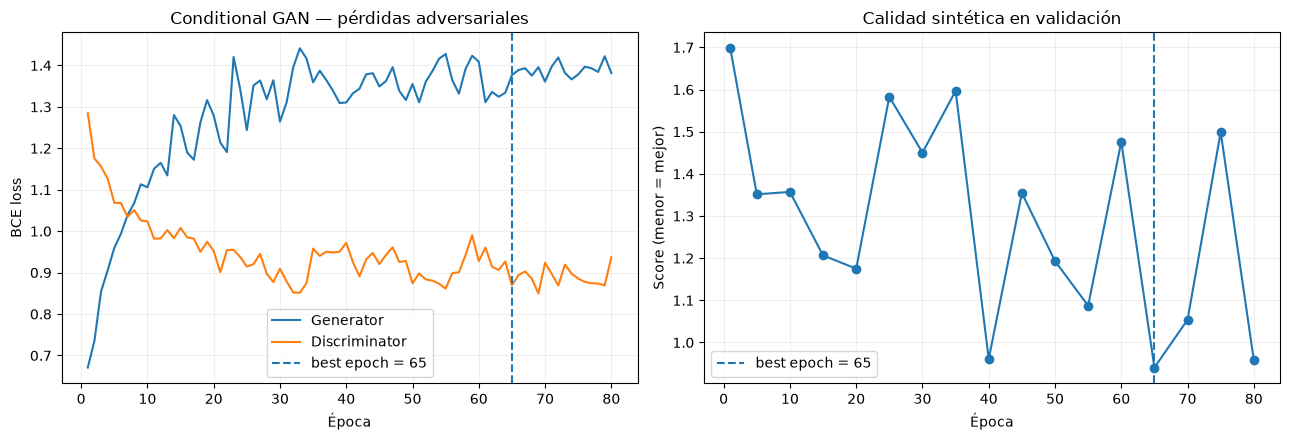

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(gan_history["epoch"], gan_history["generator_loss"], label="Generator")
axes[0].plot(gan_history["epoch"], gan_history["discriminator_loss"], label="Discriminator")
axes[0].axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
axes[0].set(title="Conditional GAN — pérdidas adversariales", xlabel="Época", ylabel="BCE loss")
axes[0].grid(alpha=0.2)
axes[0].legend()

valid_scores = gan_history.dropna(subset=["validation_score"])
axes[1].plot(valid_scores["epoch"], valid_scores["validation_score"], marker="o")
axes[1].axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
axes[1].set(title="Calidad sintética en validación", xlabel="Época", ylabel="Score (menor = mejor)")
axes[1].grid(alpha=0.2)
axes[1].legend()
plt.tight_layout()
plt.show()

En una GAN no buscamos que las dos pérdidas converjan al mismo valor exacto. Lo importante es evitar que una red domine permanentemente a la otra y, sobre todo, comprobar que la calidad sintética fuera de train mejora. Por eso el checkpoint final se selecciona por `validation_score`.

## 6. Generación de escenarios

Para una condición fija muestreamos distintos vectores `z` y los pasamos por el generador. Así obtenemos múltiples futuros BTC–ETH compatibles con el mismo contexto de mercado.

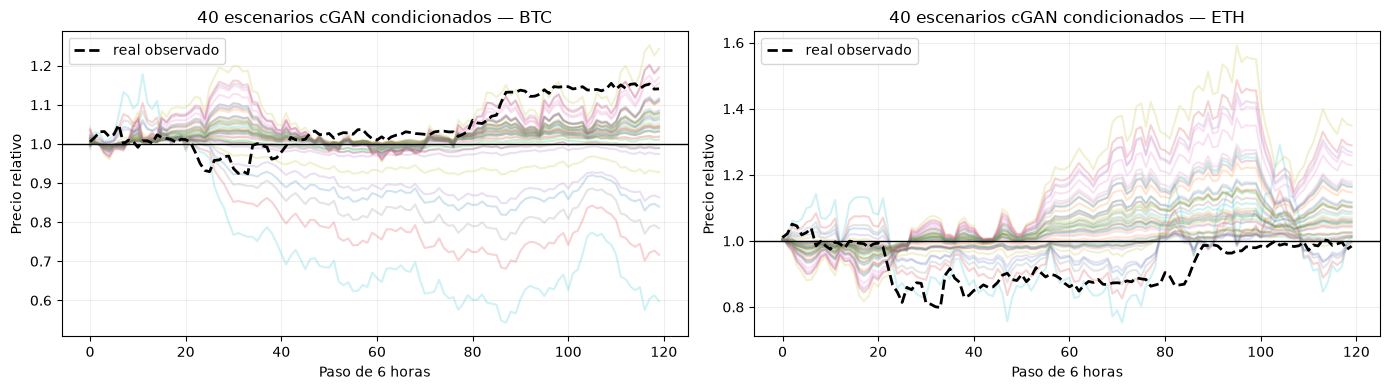

In [10]:
example_condition = np.repeat(c_test[:1], 40, axis=0)
example_generated_normalized = sample_gan(generator, example_condition, seed=20_260_818)
example_returns = (
    example_generated_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
)
real_example_returns = x_test[0] * return_scale[None, :] + return_mean[None, :]

generated_prices = np.exp(np.cumsum(example_returns, axis=1))
real_price = np.exp(np.cumsum(real_example_returns, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    axis.plot(generated_prices[:, :, asset_index].T, alpha=0.2)
    axis.plot(real_price[:, asset_index], "k--", linewidth=2, label="real observado")
    axis.axhline(1.0, color="black", linewidth=1)
    axis.set_title(f"40 escenarios cGAN condicionados — {asset}")
    axis.set_xlabel("Paso de 6 horas")
    axis.set_ylabel("Precio relativo")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## 7. Evaluación común en test

Una vez congelada la configuración y restaurado el mejor checkpoint de validación, usamos por primera vez el bloque de test. Generamos `20` escenarios por cada condición, igual que en los otros modelos condicionales.

In [11]:
test_conditions_flat = np.repeat(c_test, SCENARIOS_PER_CONDITION, axis=0)
generated_normalized_flat = sample_gan(generator, test_conditions_flat, seed=20_260_819)
generated_conditional_normalized = generated_normalized_flat.reshape(
    len(x_test), SCENARIOS_PER_CONDITION, *x_test.shape[1:]
)

reference_returns = (
    x_test * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
training_returns = (
    x_train * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float64)
generated_conditional_returns = (
    generated_conditional_normalized * return_scale[None, None, None, :]
    + return_mean[None, None, None, :]
).astype(np.float64)
generated_returns = generated_conditional_returns.reshape(
    -1, generated_conditional_returns.shape[-2], generated_conditional_returns.shape[-1]
)

evaluator = TrajectoryEvaluator(assets=assets.tolist())
print("Referencia test:", reference_returns.shape)
print("Candidato condicional:", generated_conditional_returns.shape)
print("Candidato aplanado:", generated_returns.shape)
print("Máximo |retorno normalizado generado|:", float(np.max(np.abs(generated_normalized_flat))))

Referencia test: (1826, 120, 2)
Candidato condicional: (1826, 20, 120, 2)
Candidato aplanado: (36520, 120, 2)
Máximo |retorno normalizado generado|: 11.814168930053711


### 7.1 Marginales

In [12]:
marginal_report = evaluator.evaluate_marginals(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
)
marginal_table = pd.DataFrame(marginal_report.to_records())
display(marginal_table[[
    "asset",
    "reference_standard_deviation",
    "candidate_standard_deviation",
    "reference_excess_kurtosis",
    "candidate_excess_kurtosis",
    "reference_extreme_frequency",
    "candidate_extreme_frequency",
    "normalized_wasserstein_1",
]])

,asset,reference_standard_deviation,candidate_standard_deviation,reference_excess_kurtosis,candidate_excess_kurtosis,reference_extreme_frequency,candidate_extreme_frequency,normalized_wasserstein_1
0,BTC,0.010913,0.01409,4.823215,7.226689,0.010054,0.021696,0.163526
1,ETH,0.017073,0.01941,4.760664,7.945596,0.010268,0.015781,0.109773


### 7.2 Dependencia temporal y BTC–ETH

In [13]:
temporal_report = evaluator.evaluate_temporal_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TemporalDependenceConfig(
        max_lag=20,
        volatility_window=20,
        high_volatility_quantile=0.90,
        extreme_quantile=0.99,
        extreme_clustering_window=4,
    ),
)
temporal_table = pd.DataFrame(temporal_report.to_records())
display(temporal_table[[
    "asset",
    "return_acf_rmse",
    "absolute_return_acf_rmse",
    "squared_return_acf_rmse",
    "volatility_persistence_absolute_error",
    "extreme_clustering_ratio_absolute_error",
]])

cross_asset_report = evaluator.evaluate_cross_asset_dependence(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=CrossAssetDependenceConfig(
        rolling_window=20,
        stress_quantile=0.90,
        joint_drop_quantile=0.05,
        lower_tail_quantile=0.05,
    ),
)
cross_asset_table = pd.DataFrame(cross_asset_report.to_records())
display(cross_asset_table[[
    "asset_pair",
    "reference_contemporaneous_correlation",
    "candidate_contemporaneous_correlation",
    "contemporaneous_correlation_absolute_error",
    "rolling_correlation_wasserstein_1",
    "stress_correlation_absolute_error",
    "joint_drop_probability_absolute_error",
    "lower_tail_dependence_absolute_error",
]].T)

,asset,return_acf_rmse,absolute_return_acf_rmse,squared_return_acf_rmse,volatility_persistence_absolute_error,extreme_clustering_ratio_absolute_error
0,BTC,0.084846,0.280867,0.186036,5.400871,2.479882
1,ETH,0.058822,0.314393,0.223880,6.137158,5.362557


,0
asset_pair,BTC-ETH
reference_contemporaneous_correlation,0.846945
candidate_contemporaneous_correlation,0.301987
contemporaneous_correlation_absolute_error,0.544958
rolling_correlation_wasserstein_1,0.563405
stress_correlation_absolute_error,0.63003
joint_drop_probability_absolute_error,0.021159
lower_tail_dependence_absolute_error,0.518059


### 7.3 Trayectorias, riesgo y diversidad

In [14]:
trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
trajectory_table = pd.DataFrame(trajectory_report.to_records())
display(trajectory_table.pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None))

risk_report = evaluator.evaluate_risk(
    reference_paths=reference_returns,
    candidate_paths=generated_conditional_returns,
    config=RiskMetricsConfig(
        confidence_levels=(0.95, 0.99),
        portfolio_weights=(0.60, 0.40),
        portfolio_name="portfolio_60_40",
        es_stability_repetitions=100,
        es_stability_sample_size=1_000,
        random_state=SEED,
    ),
)
risk_table = pd.DataFrame(risk_report.to_records())
display(risk_table[[
    "target",
    "confidence_level",
    "unconditional_var_absolute_error",
    "unconditional_es_absolute_error",
    "exception_rate",
    "expected_exception_rate",
    "coverage_absolute_error",
]])

diversity_report = evaluator.evaluate_diversity_and_memorization(
    reference_paths=reference_returns,
    candidate_paths=generated_returns,
    training_paths=training_returns,
    config=DiversityMemorizationConfig(
        max_paths_per_set=2_000,
        projection_dimensions=24,
        neighbor_candidates=8,
        near_memorization_quantile=0.01,
        coverage_radius_quantile=0.95,
        discriminator_repetitions=5,
        random_state=SEED,
    ),
)
diversity_table = pd.DataFrame(diversity_report.to_records())
display(diversity_table[[
    "candidate_unique_fraction",
    "candidate_near_duplicate_fraction",
    "exact_training_match_fraction",
    "near_memorization_fraction",
    "reference_coverage_fraction",
    "regime_total_variation_distance",
    "discriminator_accuracy_mean",
]].T.rename(columns={0: "valor"}))

,BTC,ETH
metric,,
final_cumulative_return,0.350904,0.543894
intrahorizon_maximum_return,0.171439,0.323375
intrahorizon_minimum_return,0.339837,0.397893
maximum_drawdown,0.356521,0.632423
maximum_drawdown_duration_steps,0.576767,1.164741
realized_volatility,1.394846,1.962857
time_to_minimum_value_steps,0.413388,0.773920


,target,confidence_level,unconditional_var_absolute_error,unconditional_es_absolute_error,exception_rate,expected_exception_rate,coverage_absolute_error
0,BTC,0.95,0.045943,0.102259,0.146769,0.05,0.096769
1,BTC,0.99,0.139456,0.175010,0.066265,0.01,0.056265
2,ETH,0.95,0.320325,0.356876,0.496166,0.05,0.446166
3,ETH,0.99,0.378726,0.391734,0.479189,0.01,0.469189
4,portfolio_60_40,0.95,0.103747,0.087291,0.269989,0.05,0.219989
5,portfolio_60_40,0.99,0.078997,0.062910,0.204272,0.01,0.194272


,valor
candidate_unique_fraction,1.000000
candidate_near_duplicate_fraction,1.000000
exact_training_match_fraction,0.000000
near_memorization_fraction,0.337500
reference_coverage_fraction,0.952903
regime_total_variation_distance,0.266468
discriminator_accuracy_mean,1.000000


### 7.4 Diagnósticos visuales comparables

Mostramos los mismos tipos de gráficos que en los otros generadores: retornos marginales y acumulados, más calibración de riesgo para la cartera 60/40.

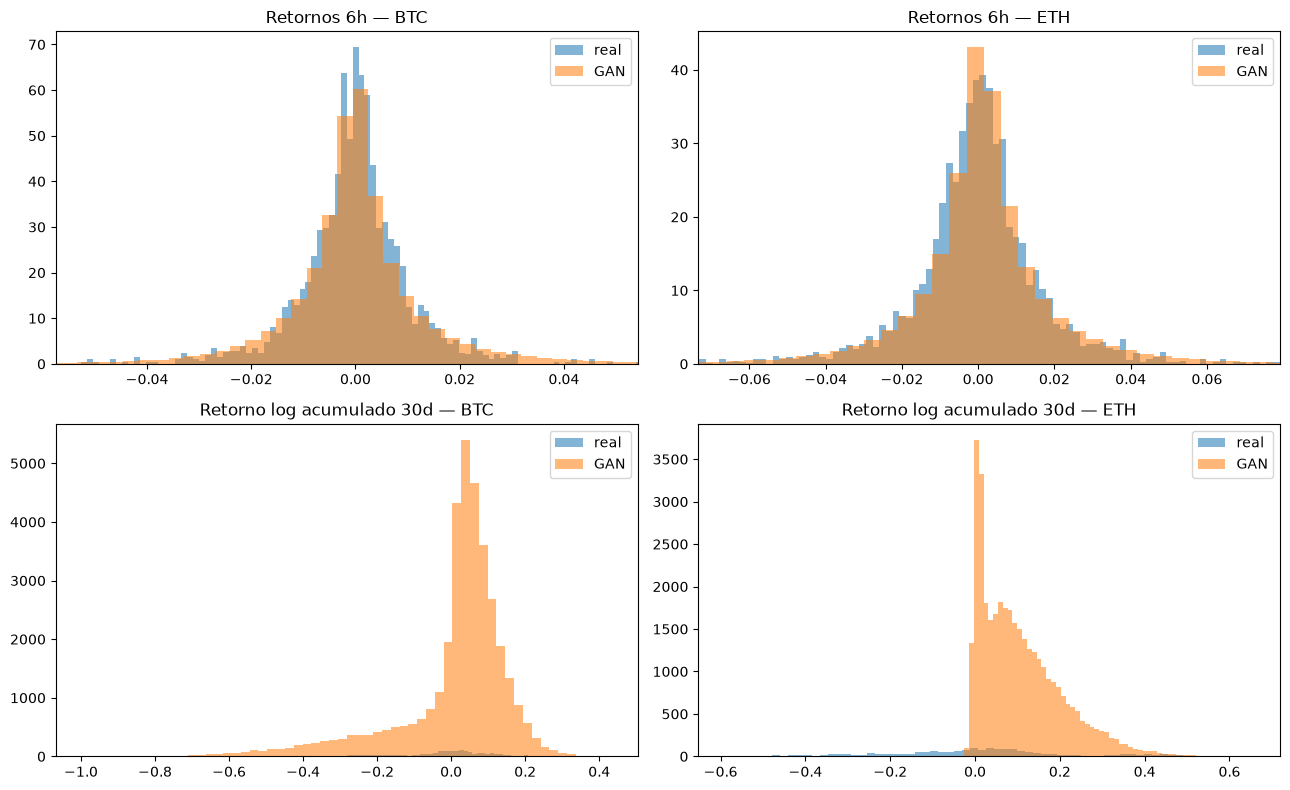

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for asset_index, asset in enumerate(assets):
    axes[0, asset_index].hist(reference_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="real")
    axes[0, asset_index].hist(generated_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="GAN")
    axes[0, asset_index].set_title(f"Retornos 6h — {asset}")
    axes[0, asset_index].set_xlim(
        np.quantile(reference_returns[:, :, asset_index], 0.001),
        np.quantile(reference_returns[:, :, asset_index], 0.999),
    )
    axes[0, asset_index].legend()
    axes[1, asset_index].hist(reference_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="real")
    axes[1, asset_index].hist(generated_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="GAN")
    axes[1, asset_index].set_title(f"Retorno log acumulado 30d — {asset}")
    axes[1, asset_index].legend()
plt.tight_layout()
plt.show()

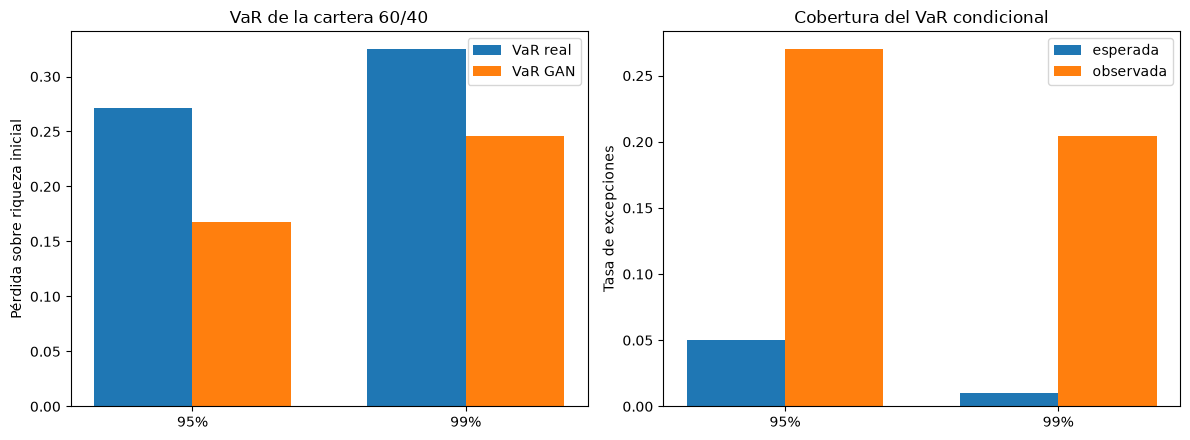

In [16]:
portfolio_risk = risk_table.loc[risk_table["target"].eq("portfolio_60_40")]
risk_positions = np.arange(len(portfolio_risk))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(risk_positions - 0.18, portfolio_risk["reference_unconditional_var"], 0.36, label="VaR real")
axes[0].bar(risk_positions + 0.18, portfolio_risk["candidate_unconditional_var"], 0.36, label="VaR GAN")
axes[0].set_xticks(risk_positions, [f"{level:.0%}" for level in portfolio_risk["confidence_level"]])
axes[0].set(title="VaR de la cartera 60/40", ylabel="Pérdida sobre riqueza inicial")
axes[0].legend()

axes[1].bar(risk_positions - 0.18, portfolio_risk["expected_exception_rate"], 0.36, label="esperada")
axes[1].bar(risk_positions + 0.18, portfolio_risk["exception_rate"], 0.36, label="observada")
axes[1].set_xticks(risk_positions, [f"{level:.0%}" for level in portfolio_risk["confidence_level"]])
axes[1].set(title="Cobertura del VaR condicional", ylabel="Tasa de excepciones")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.5 Control con objetivos no solapados

Repetimos marginales y métricas de trayectoria con una ancla cada 120 velas. Es un control de sensibilidad; quedan pocas observaciones y no debe usarse como estimación precisa de colas.

In [17]:
non_overlapping_ids = np.arange(0, len(x_test), 120)
non_overlapping_conditions_flat = np.repeat(
    c_test[non_overlapping_ids], SCENARIOS_PER_CONDITION, axis=0
)
non_overlapping_generated_normalized = sample_gan(
    generator, non_overlapping_conditions_flat, seed=20_260_820
)
non_overlapping_reference = reference_returns[non_overlapping_ids]
non_overlapping_generated_returns = (
    non_overlapping_generated_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float64)

non_overlapping_marginal_report = evaluator.evaluate_marginals(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
)
non_overlapping_trajectory_report = evaluator.evaluate_trajectories(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_generated_returns,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
print("Anclas no solapadas:", len(non_overlapping_ids))
display(pd.DataFrame(non_overlapping_marginal_report.to_records())[[
    "asset", "normalized_wasserstein_1"
]].rename(columns={"normalized_wasserstein_1": "W1 marginal normalizada"}))
display(pd.DataFrame(non_overlapping_trajectory_report.to_records()).pivot(
    index="metric", columns="asset", values="normalized_wasserstein_1"
).rename_axis(columns=None))

Anclas no solapadas: 16


,asset,W1 marginal normalizada
0,BTC,0.143737
1,ETH,0.099490


,BTC,ETH
metric,,
final_cumulative_return,0.311483,0.454008
intrahorizon_maximum_return,0.229645,0.168584
intrahorizon_minimum_return,0.236356,0.327566
maximum_drawdown,0.507161,0.582001
maximum_drawdown_duration_steps,0.714417,0.726333
realized_volatility,1.339313,1.756549
time_to_minimum_value_steps,0.436710,0.634404


## 8. Impacto de la augmentación sintética en un modelo downstream

Usamos exactamente el mismo experimento del Normalizing Flow:

- **Entrada:** las 14 variables de condición.
- **Objetivo:** máximo drawdown a 30 días de una cartera 60 % BTC / 40 % ETH.
- **Modelo:** la misma MLP `64 → 32 → 1` con `dropout=0.10`.
- **Validación y test:** siempre reales.
- **Mezclas:** `0 %`, `+25 %`, `+50 %`, `+100 %` de sintéticos adicionales respecto al train real.

Las trayectorias sintéticas se generan únicamente condicionando con estados del bloque de entrenamiento.

In [18]:
DOWNSTREAM_SEED = 2026
AUGMENTATION_RATIOS = (0.00, 0.25, 0.50, 1.00)
GENERATION_BATCH_SIZE = 256

rng = np.random.default_rng(DOWNSTREAM_SEED)
synthetic_order = rng.permutation(len(c_train))
synthetic_train_conditions = c_train[synthetic_order]

synthetic_chunks = []
for batch_index, start in enumerate(range(0, len(synthetic_train_conditions), GENERATION_BATCH_SIZE)):
    stop = min(start + GENERATION_BATCH_SIZE, len(synthetic_train_conditions))
    chunk = sample_gan(
        generator,
        synthetic_train_conditions[start:stop],
        seed=DOWNSTREAM_SEED + 10_000 + batch_index,
    )
    synthetic_chunks.append(chunk)
    print(f"Generadas {stop:4d}/{len(synthetic_train_conditions)} trayectorias sintéticas de train")

synthetic_train_normalized = np.concatenate(synthetic_chunks, axis=0)
synthetic_train_returns = (
    synthetic_train_normalized * return_scale[None, None, :]
    + return_mean[None, None, :]
).astype(np.float32)

augmentation_manifest = []
for ratio in AUGMENTATION_RATIOS:
    synthetic_count = int(round(len(x_train) * ratio))
    augmentation_manifest.append({
        "dataset": "real_only" if ratio == 0 else f"real_plus_{int(ratio*100)}pct_gan",
        "real_samples": len(x_train),
        "synthetic_samples": synthetic_count,
        "total_samples": len(x_train) + synthetic_count,
        "synthetic_addition_vs_real": ratio,
        "synthetic_share_of_total": synthetic_count / (len(x_train) + synthetic_count),
    })

augmentation_manifest = pd.DataFrame(augmentation_manifest)
display(augmentation_manifest)

Generadas  256/4710 trayectorias sintéticas de train
Generadas  512/4710 trayectorias sintéticas de train
Generadas  768/4710 trayectorias sintéticas de train
Generadas 1024/4710 trayectorias sintéticas de train
Generadas 1280/4710 trayectorias sintéticas de train
Generadas 1536/4710 trayectorias sintéticas de train
Generadas 1792/4710 trayectorias sintéticas de train
Generadas 2048/4710 trayectorias sintéticas de train
Generadas 2304/4710 trayectorias sintéticas de train
Generadas 2560/4710 trayectorias sintéticas de train
Generadas 2816/4710 trayectorias sintéticas de train
Generadas 3072/4710 trayectorias sintéticas de train
Generadas 3328/4710 trayectorias sintéticas de train
Generadas 3584/4710 trayectorias sintéticas de train
Generadas 3840/4710 trayectorias sintéticas de train
Generadas 4096/4710 trayectorias sintéticas de train
Generadas 4352/4710 trayectorias sintéticas de train
Generadas 4608/4710 trayectorias sintéticas de train
Generadas 4710/4710 trayectorias sintéticas de

,dataset,real_samples,synthetic_samples,total_samples,synthetic_addition_vs_real,synthetic_share_of_total
0,real_only,4710,0,4710,0.00,0.000000
1,real_plus_25pct_gan,4710,1178,5888,0.25,0.200068
2,real_plus_50pct_gan,4710,2355,7065,0.50,0.333333
3,real_plus_100pct_gan,4710,4710,9420,1.00,0.500000


In [19]:
@dataclass(frozen=True)
class DownstreamConfig:
    hidden_dim_1: int = 64
    hidden_dim_2: int = 32
    dropout: float = 0.10
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 128
    epochs: int = 100
    patience: int = 15
    seed: int = 2026


class DrawdownMLP(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim_1, config.hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim_2, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


def maximum_drawdown_magnitude(log_return_paths, btc_weight=0.60, eth_weight=0.40):
    paths = np.asarray(log_return_paths, dtype=np.float64)
    cumulative = np.cumsum(paths, axis=1)
    gross = np.exp(cumulative)
    portfolio = btc_weight * gross[:, :, 0] + eth_weight * gross[:, :, 1]
    portfolio = np.concatenate([np.ones((len(paths), 1)), portfolio], axis=1)
    running_peak = np.maximum.accumulate(portfolio, axis=1)
    drawdown = portfolio / running_peak - 1.0
    return (-drawdown.min(axis=1)).astype(np.float32)


def set_downstream_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def downstream_loader(x, y, *, batch_size, shuffle, seed):
    loader_generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        TensorDataset(
            torch.as_tensor(x, dtype=torch.float32),
            torch.as_tensor(y, dtype=torch.float32),
        ),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=loader_generator if shuffle else None,
        num_workers=0,
    )


def mean_mse(model, loader):
    model.eval()
    total, count = 0.0, 0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = criterion(model(xb), yb)
            total += loss.item() * len(xb)
            count += len(xb)
    return total / count


def train_downstream(train_x, train_y, validation_x, validation_y, target_mean, target_std, config):
    set_downstream_seed(config.seed)
    downstream_model = DrawdownMLP(train_x.shape[1], config).to(DEVICE)

    train_y_scaled = (train_y - target_mean) / target_std
    validation_y_scaled = (validation_y - target_mean) / target_std

    train_loader_ds = downstream_loader(
        train_x, train_y_scaled, batch_size=config.batch_size, shuffle=True, seed=config.seed
    )
    validation_loader_ds = downstream_loader(
        validation_x, validation_y_scaled, batch_size=config.batch_size, shuffle=False, seed=config.seed
    )

    criterion = nn.MSELoss()
    optimizer_ds = torch.optim.AdamW(
        downstream_model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ds, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )

    best_state_ds = None
    best_validation_ds = math.inf
    best_epoch_ds = 0
    epochs_without_improvement = 0
    history_ds = []

    for epoch in range(1, config.epochs + 1):
        downstream_model.train()
        total, count = 0.0, 0
        for xb, yb in train_loader_ds:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_ds.zero_grad(set_to_none=True)
            loss = criterion(downstream_model(xb), yb)
            loss.backward()
            optimizer_ds.step()
            total += loss.item() * len(xb)
            count += len(xb)

        train_loss = total / count
        validation_loss = mean_mse(downstream_model, validation_loader_ds)
        scheduler.step(validation_loss)
        history_ds.append({
            "epoch": epoch,
            "train_mse_scaled": train_loss,
            "validation_mse_scaled": validation_loss,
        })

        if validation_loss < best_validation_ds - 1e-8:
            best_validation_ds = validation_loss
            best_epoch_ds = epoch
            best_state_ds = copy.deepcopy(downstream_model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config.patience:
            break

    downstream_model.load_state_dict(best_state_ds)
    return downstream_model, pd.DataFrame(history_ds), best_epoch_ds, best_validation_ds


def downstream_predict(model, x, target_mean, target_std, batch_size=128):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.as_tensor(x[start:start+batch_size], dtype=torch.float32, device=DEVICE)
            scaled = model(xb).cpu().numpy()
            predictions.append(scaled * target_std + target_mean)
    return np.concatenate(predictions)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    residual = y_pred - y_true
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual**2))
    denominator = np.sum((y_true - y_true.mean())**2)
    r2 = 1.0 - np.sum(residual**2) / denominator
    threshold_90 = np.quantile(y_true, 0.90)
    tail_mae_90 = np.mean(np.abs(residual[y_true >= threshold_90]))
    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "tail_mae_worst_10pct": float(tail_mae_90),
    }


DOWNSTREAM_CONFIG = DownstreamConfig()
pd.Series(asdict(DOWNSTREAM_CONFIG), name="valor").to_frame()

,valor
hidden_dim_1,64.0000
hidden_dim_2,32.0000
dropout,0.1000
learning_rate,0.0010
weight_decay,0.0001
batch_size,128.0000
epochs,100.0000
patience,15.0000
seed,2026.0000


In [20]:
train_real_returns = (
    x_train * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)
validation_real_returns = (
    x_validation * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)
test_real_returns = (
    x_test * return_scale[None, None, :] + return_mean[None, None, :]
).astype(np.float32)

train_real_y = maximum_drawdown_magnitude(train_real_returns)
synthetic_train_y = maximum_drawdown_magnitude(synthetic_train_returns)
validation_y = maximum_drawdown_magnitude(validation_real_returns)
test_y = maximum_drawdown_magnitude(test_real_returns)

target_mean = float(train_real_y.mean())
target_std = float(train_real_y.std(ddof=0))

print(f"Target train real: mean={target_mean:.6f}, std={target_std:.6f}")
print(f"Validación real: {len(validation_y)} | Test real: {len(test_y)}")

downstream_rows = []
downstream_histories = {}

for ratio_index, ratio in enumerate(AUGMENTATION_RATIOS):
    synthetic_count = int(round(len(c_train) * ratio))

    train_x_ds = np.concatenate(
        [c_train, synthetic_train_conditions[:synthetic_count]], axis=0
    ).astype(np.float32)
    train_y_ds = np.concatenate(
        [train_real_y, synthetic_train_y[:synthetic_count]], axis=0
    ).astype(np.float32)

    dataset_seed = DOWNSTREAM_SEED if ratio == 0 else DOWNSTREAM_SEED + ratio_index
    order = np.random.default_rng(dataset_seed).permutation(len(train_x_ds))
    train_x_ds = train_x_ds[order]
    train_y_ds = train_y_ds[order]

    label = "real_only" if ratio == 0 else f"real_plus_{int(ratio*100)}pct_gan"
    print(f"\nEntrenando {label}: real={len(c_train)}, sintético={synthetic_count}, total={len(train_x_ds)}")

    downstream_model, history_ds, best_epoch_ds, best_val_ds = train_downstream(
        train_x_ds,
        train_y_ds,
        c_validation,
        validation_y,
        target_mean,
        target_std,
        DOWNSTREAM_CONFIG,
    )

    validation_pred = downstream_predict(
        downstream_model, c_validation, target_mean, target_std, DOWNSTREAM_CONFIG.batch_size
    )
    test_pred = downstream_predict(
        downstream_model, c_test, target_mean, target_std, DOWNSTREAM_CONFIG.batch_size
    )

    validation_metrics = regression_metrics(validation_y, validation_pred)
    test_metrics = regression_metrics(test_y, test_pred)

    downstream_histories[label] = history_ds
    downstream_rows.append({
        "dataset": label,
        "real_train": len(c_train),
        "synthetic_train": synthetic_count,
        "total_train": len(train_x_ds),
        "best_epoch": best_epoch_ds,
        "validation_mae": validation_metrics["mae"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_r2": test_metrics["r2"],
        "test_tail_mae_worst_10pct": test_metrics["tail_mae_worst_10pct"],
    })

    print(
        f"best_epoch={best_epoch_ds} | "
        f"val_MAE={validation_metrics['mae']:.4%} | "
        f"test_MAE={test_metrics['mae']:.4%} | "
        f"tail_MAE={test_metrics['tail_mae_worst_10pct']:.4%}"
    )

downstream_comparison = pd.DataFrame(downstream_rows)

display(
    downstream_comparison.assign(
        validation_mae=lambda d: 100 * d["validation_mae"],
        test_mae=lambda d: 100 * d["test_mae"],
        test_rmse=lambda d: 100 * d["test_rmse"],
        test_tail_mae_worst_10pct=lambda d: 100 * d["test_tail_mae_worst_10pct"],
    ).rename(columns={
        "validation_mae": "validation_MAE_%",
        "test_mae": "test_MAE_%",
        "test_rmse": "test_RMSE_%",
        "test_tail_mae_worst_10pct": "test_tail_MAE_%",
    })
)

baseline_mae = downstream_comparison.loc[
    downstream_comparison["dataset"].eq("real_only"), "test_mae"
].iloc[0]
best_row = downstream_comparison.loc[downstream_comparison["test_mae"].idxmin()]
relative_improvement = 100 * (baseline_mae - best_row["test_mae"]) / baseline_mae

print(
    f"\nMejor MAE test: {best_row['dataset']} = {best_row['test_mae']:.4%} "
    f"({relative_improvement:.2f}% de mejora relativa frente a real_only)"
)

Target train real: mean=0.174663, std=0.095150
Validación real: 1832 | Test real: 1826

Entrenando real_only: real=4710, sintético=0, total=4710


best_epoch=2 | val_MAE=4.7516% | test_MAE=7.9550% | tail_MAE=21.9275%

Entrenando real_plus_25pct_gan: real=4710, sintético=1178, total=5888


best_epoch=2 | val_MAE=4.6136% | test_MAE=7.3352% | tail_MAE=22.5311%

Entrenando real_plus_50pct_gan: real=4710, sintético=2355, total=7065


best_epoch=2 | val_MAE=4.7914% | test_MAE=7.0077% | tail_MAE=21.8498%

Entrenando real_plus_100pct_gan: real=4710, sintético=4710, total=9420


best_epoch=2 | val_MAE=4.7852% | test_MAE=6.5808% | tail_MAE=22.6548%


,dataset,real_train,synthetic_train,total_train,best_epoch,validation_MAE_%,test_MAE_%,test_RMSE_%,test_r2,test_tail_MAE_%
0,real_only,4710,0,4710,2,4.751624,7.955042,10.070963,-0.467465,21.927494
1,real_plus_25pct_gan,4710,1178,5888,2,4.613573,7.335204,9.804179,-0.390747,22.531122
2,real_plus_50pct_gan,4710,2355,7065,2,4.791412,7.007658,9.415403,-0.282637,21.849770
3,real_plus_100pct_gan,4710,4710,9420,2,4.785160,6.580789,9.427377,-0.285901,22.654800



Mejor MAE test: real_plus_100pct_gan = 6.5808% (17.28% de mejora relativa frente a real_only)


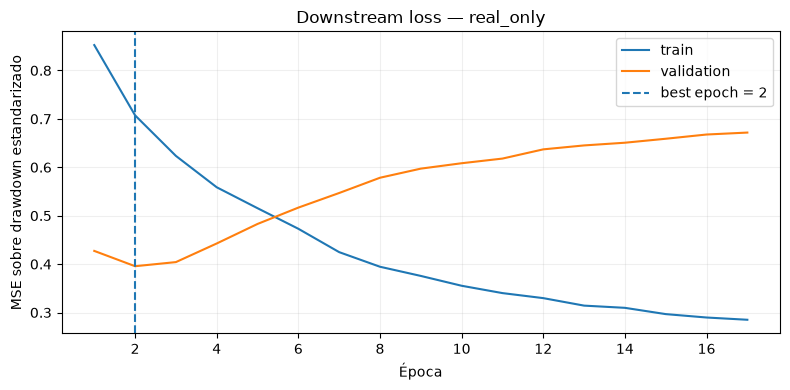

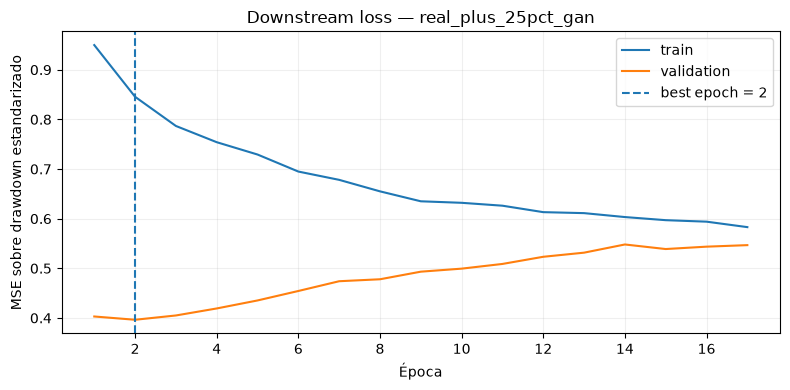

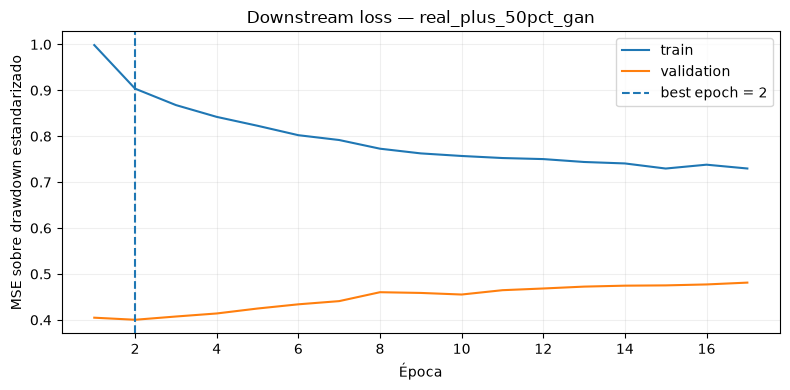

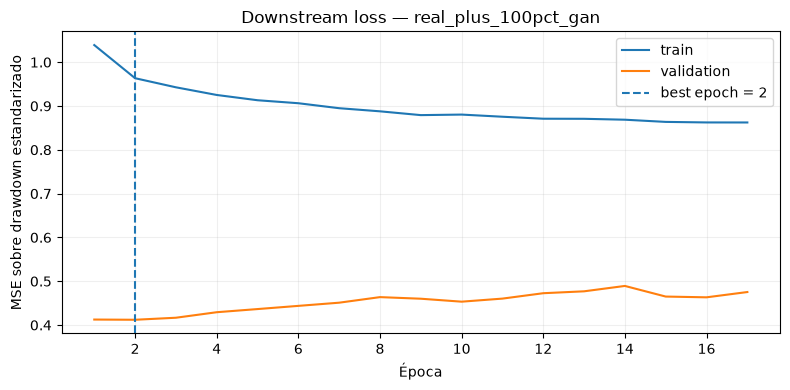

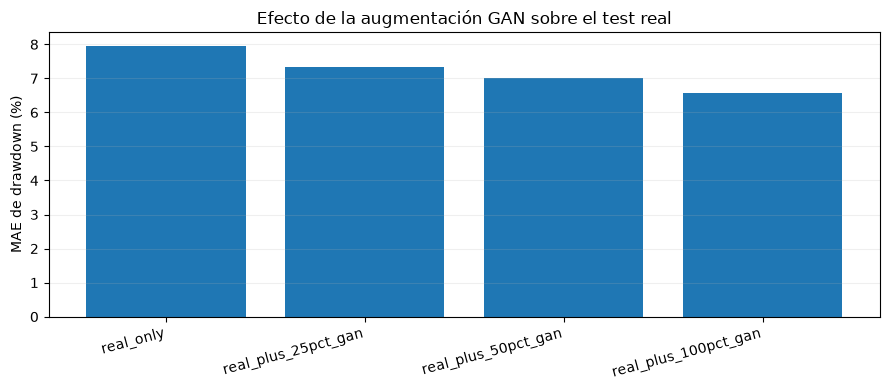

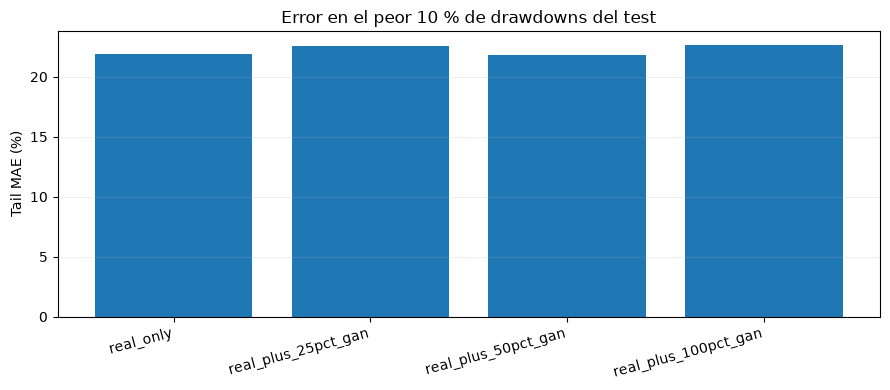

In [21]:
for label, history_ds in downstream_histories.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history_ds["epoch"], history_ds["train_mse_scaled"], label="train")
    ax.plot(history_ds["epoch"], history_ds["validation_mse_scaled"], label="validation")
    best_epoch_plot = int(
        downstream_comparison.loc[
            downstream_comparison["dataset"].eq(label), "best_epoch"
        ].iloc[0]
    )
    ax.axvline(best_epoch_plot, linestyle="--", label=f"best epoch = {best_epoch_plot}")
    ax.set_title(f"Downstream loss — {label}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE sobre drawdown estandarizado")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()

positions = np.arange(len(downstream_comparison))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(positions, 100 * downstream_comparison["test_mae"])
ax.set_xticks(positions)
ax.set_xticklabels(downstream_comparison["dataset"], rotation=15, ha="right")
ax.set_ylabel("MAE de drawdown (%)")
ax.set_title("Efecto de la augmentación GAN sobre el test real")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(positions, 100 * downstream_comparison["test_tail_mae_worst_10pct"])
ax.set_xticks(positions)
ax.set_xticklabels(downstream_comparison["dataset"], rotation=15, ha="right")
ax.set_ylabel("Tail MAE (%)")
ax.set_title("Error en el peor 10 % de drawdowns del test")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 8.1 Interpretación

Esta sección responde directamente a la pregunta del taller: **¿qué ocurre cuando añadimos datos generados por la GAN manteniendo fijo el modelo predictivo?**

La lectura debe hacerse con tres reglas:

1. validación y test permanecen 100 % reales;
2. arquitectura, inicialización, optimizador y escalado del target son iguales entre mezclas;
3. la utilidad downstream debe interpretarse con MAE, `R²` y error de cola, no únicamente con la mejor cifra aislada.

## 9. Guardado reproducible

In [22]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tuning_table.to_csv(OUTPUT_DIR / "tuning_results.csv", index=False)
gan_history.to_csv(OUTPUT_DIR / "gan_training_history.csv", index=False)
downstream_comparison.to_csv(OUTPUT_DIR / "downstream_comparison.csv", index=False)
for label, history_ds in downstream_histories.items():
    history_ds.to_csv(OUTPUT_DIR / f"downstream_history_{label}.csv", index=False)

checkpoint = {
    "selected_config": asdict(SELECTED_CONFIG),
    "generator_state_dict": generator.state_dict(),
    "discriminator_state_dict": discriminator.state_dict(),
    "best_epoch_1_based": best_epoch,
    "best_validation_score": best_validation_score,
    "best_validation_details": best_validation_details,
}
torch.save(checkpoint, OUTPUT_DIR / "conditional_gan_best.pt")

np.savez_compressed(
    OUTPUT_DIR / "test_scenarios.npz",
    generated_normalized=generated_normalized_flat,
    generated_conditional_returns=generated_conditional_returns,
    generated_returns=generated_returns,
    real_normalized=x_test,
    real_returns=reference_returns,
    conditions=c_test,
    assets=assets,
)

metadata = {
    "model": "conditional_gan_bce",
    "selected_config": asdict(SELECTED_CONFIG),
    "selection": {
        "metric": "validation_financial_quality_score",
        "validation_subset_size": VALIDATION_SELECTION_SIZE,
        "validation_draws": VALIDATION_DRAWS,
        "best_epoch_1_based": best_epoch,
        "best_validation_score": best_validation_score,
        "best_validation_details": best_validation_details,
        "test_used_for_selection": False,
    },
    "tuning": tuning_table.to_dict(orient="records"),
    "train_samples": len(x_train),
    "validation_samples": len(x_validation),
    "test_samples": len(x_test),
    "scenarios_per_condition": SCENARIOS_PER_CONDITION,
    "evaluation": {
        "marginal": marginal_report.to_dict(),
        "temporal": temporal_report.to_dict(),
        "cross_asset": cross_asset_report.to_dict(),
        "trajectory": trajectory_report.to_dict(),
        "risk": risk_report.to_dict(),
        "diversity_and_memorization": diversity_report.to_dict(),
    },
    "downstream": {
        "task": "predict_30d_maximum_drawdown_magnitude_60_40_btc_eth",
        "augmentation_ratios": list(AUGMENTATION_RATIOS),
        "configuration": asdict(DOWNSTREAM_CONFIG),
        "comparison": downstream_comparison.to_dict(orient="records"),
        "validation_and_test": "real_only",
    },
    "non_overlapping_sensitivity": {
        "anchors": len(non_overlapping_ids),
        "marginal": non_overlapping_marginal_report.to_dict(),
        "trajectory": non_overlapping_trajectory_report.to_dict(),
    },
}
(OUTPUT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("Artefactos guardados en:", OUTPUT_DIR.relative_to(ROOT))

Artefactos guardados en: outputs/conditional_gan_best


## Conclusión

Este notebook incorpora una **Conditional GAN** como tercer generador neuronal del proyecto manteniendo el mismo problema, datos y protocolo de evaluación que CVAE y Normalizing Flow.

La selección del modelo se realiza exclusivamente con validación mediante un score de calidad sintética, porque las pérdidas adversariales no equivalen directamente a fidelidad financiera. Una vez congelado el checkpoint, el `TrajectoryEvaluator` común permite analizar marginales, dependencia temporal y BTC–ETH, trayectorias, riesgo y diversidad/memorización.

La sección downstream completa el segundo objetivo del taller: comparar `real-only`, `+25 %`, `+50 %` y `+100 %` de sintéticos GAN utilizando exactamente la misma MLP de drawdown y manteniendo validación/test exclusivamente reales. La conclusión final debe apoyarse en los resultados ejecutados y compararse con CVAE, Flow y el modelo simple.